In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
import gc

In [3]:
data = np.load('chb_mit_dataset_2seconds_epoch.npz')
X = data['X']
y = data['y']

In [4]:
# ============================================
# CELL 12: Train / Validation / Test Split
# ============================================

print("=" * 60)
print("✂️ SPLITTING DATA")
print("=" * 60)

# Reshape for model: (samples, channels, time) → (samples, time, channels)
X_reshaped = np.transpose(X, (0, 2, 1))

print(f"\n📐 Reshaped: {X.shape} → {X_reshaped.shape}")
print(f"   • Samples: {X_reshaped.shape[0]}")
print(f"   • Time steps: {X_reshaped.shape[1]}")
print(f"   • Channels: {X_reshaped.shape[2]}")

# Split: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X_reshaped, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Free memory
del X, X_reshaped, X_temp, y_temp
gc.collect()

print(f"\n📊 Split Results:")
print(f"   ┌─────────────┬─────────┬─────────┬─────────┐")
print(f"   │ Set         │ Samples │ Seizure │ Normal  │")
print(f"   ├─────────────┼─────────┼─────────┼─────────┤")
print(f"   │ Train       │ {len(X_train):>7} │ {int(np.sum(y_train)):>7} │ {int(len(y_train) - np.sum(y_train)):>7} │")
print(f"   │ Validation  │ {len(X_val):>7} │ {int(np.sum(y_val)):>7} │ {int(len(y_val) - np.sum(y_val)):>7} │")
print(f"   │ Test        │ {len(X_test):>7} │ {int(np.sum(y_test)):>7} │ {int(len(y_test) - np.sum(y_test)):>7} │")
print(f"   └─────────────┴─────────┴─────────┴─────────┘")

print(f"\n📐 Shapes:")
print(f"   • X_train: {X_train.shape}")
print(f"   • X_val:   {X_val.shape}")
print(f"   • X_test:  {X_test.shape}")

print("\n" + "=" * 60)
print("✅ Data split complete!")
print("=" * 60)


📊 Split Results:
   ┌─────────────┬─────────┬─────────┬─────────┐
   │ Set         │ Samples │ Seizure │ Normal  │
   ├─────────────┼─────────┼─────────┼─────────┤
   │ Train       │   10590 │    3530 │    7060 │
   │ Validation  │    2269 │     756 │    1513 │
   │ Test        │    2270 │     757 │    1513 │
   └─────────────┴─────────┴─────────┴─────────┘

📐 Shapes:
   • X_train: (10590, 256, 18)
   • X_val:   (2269, 256, 18)
   • X_test:  (2270, 256, 18)

✅ Data split complete!


In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input


def build_seizure_model(input_shape):
    model = models.Sequential([
        # Yeni Standart: Giriş katmanını ayrı bir Input objesi olarak tanımlıyoruz
        Input(shape=input_shape),

        # 1. Katman
        layers.Conv1D(filters=32, kernel_size=3, activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),

        # 2. Katman
        layers.Conv1D(filters=64, kernel_size=3, activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),

        # 3. Katman
        layers.Conv1D(filters=128, kernel_size=3, activation='relu'),
        layers.GlobalAveragePooling1D(),

        # Sınıflandırma
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),

        # Çıkış (Binary Classification)
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.Precision()]
    )

    return model


# Kullanım aynı:
input_shape = (X_train.shape[1], X_train.shape[2])
model = build_seizure_model(input_shape)

In [6]:
model.summary()

 Non-trainable params: 192 (768.00 B)

In [7]:
# Modelin takılıp kalmasını önlemek için Callback'ler
callbacks = [
    # 5 epoch boyunca gelişme olmazsa öğrenme oranını düşür (LR Annealing)
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001),

    # Val_loss artık düşmüyorsa eğitimi durdur (Zaman tasarrufu)
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks
)

331/331 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.9502 - loss: 0.1244 - precision: 0.9175 - recall: 0.9337 - val_accuracy: 0.8378 - val_loss: 0.4470 - val_precision: 0.7095 - val_recall: 0.8690 - learning_rate: 5.0000e-04


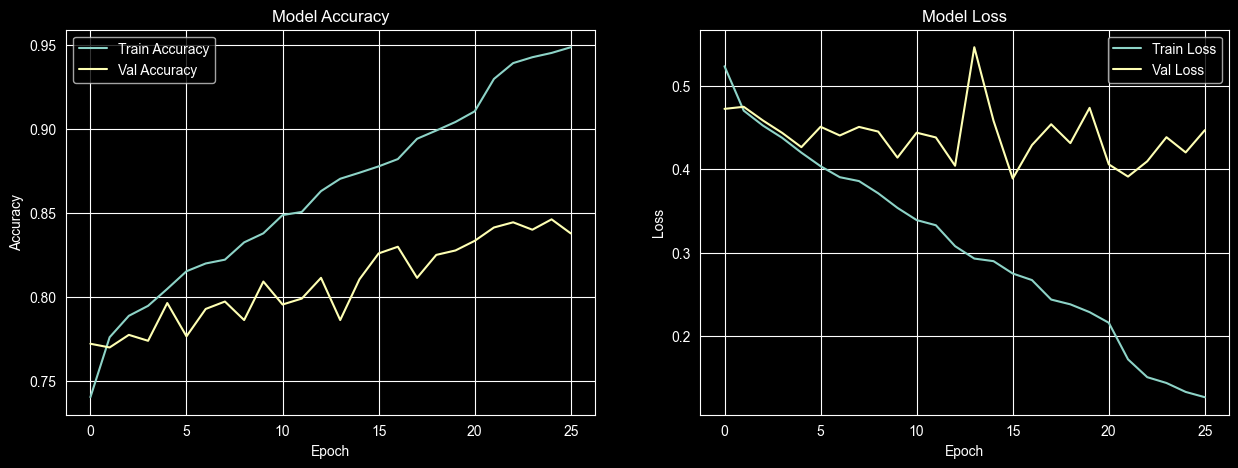

In [8]:
import matplotlib.pyplot as plt


def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Accuracy Grafiği
    ax1.plot(history.history['accuracy'], label='Train Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    # Loss Grafiği
    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Val Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()

    plt.show()


plot_history(history)

In [9]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Test seti üzerinde tahmin yap
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)  # 0.5 eşik değerine göre sınıfla

# Matrisi hesapla
cm = confusion_matrix(y_test, y_pred)

# Görselleştir
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Seizure'],
            yticklabels=['Normal', 'Seizure'])
plt.title('Confusion Matrix - Test Data')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Detaylı Rapor (Precision, Recall, F1-Score)
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Seizure']))


📋 Classification Report:
              precision    recall  f1-score   support

      Normal       0.87      0.90      0.88      1513
     Seizure       0.79      0.73      0.76       757

    accuracy                           0.84      2270
   macro avg       0.83      0.81      0.82      2270
weighted avg       0.84      0.84      0.84      2270



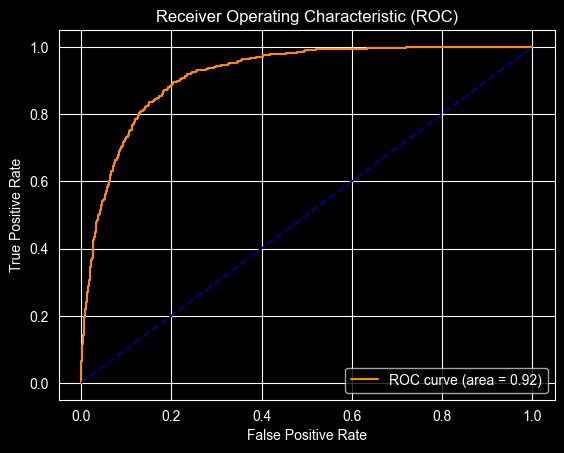

In [10]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()